In [3]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from vtools import plot as vplt

import uncertainties as un
import uncertainties.unumpy as unp
from uncertainties.unumpy import nominal_values as nom
from uncertainties.unumpy import std_devs as std
from scipy import stats, optimize

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Data

In [4]:
dat = pd.read_pickle('data/vaterite_processed.pkl')

no_high_mg = (dat.solution_start['Mg/Ca'] < 3).values  # exclude high Mg point that grew aragonite
vaterite_growth = dat.overgrowth.F_V.values >= 0  # only select data where vaterite grew


/home/oscar/.venvs/py3/lib/python3.14/site-packages/pandas/core/ops/array_ops.py:131: FutureWarning: AffineScalarFunc.__lt__() is deprecated. It will be removed in a future release.
  result = libops.scalar_compare(x.ravel(), y, op)
/tmp/ipykernel_203103/2414160451.py:4: FutureWarning: AffineScalarFunc.__ge__() is deprecated. It will be removed in a future release.
  vaterite_growth = dat.overgrowth.F_V.values >= 0  # only select data where vaterite grew


## Physical Characterstics

### How does the amount of new growth change with solution chemistry?

In [7]:
sx = ax.get_shared_y_axes()

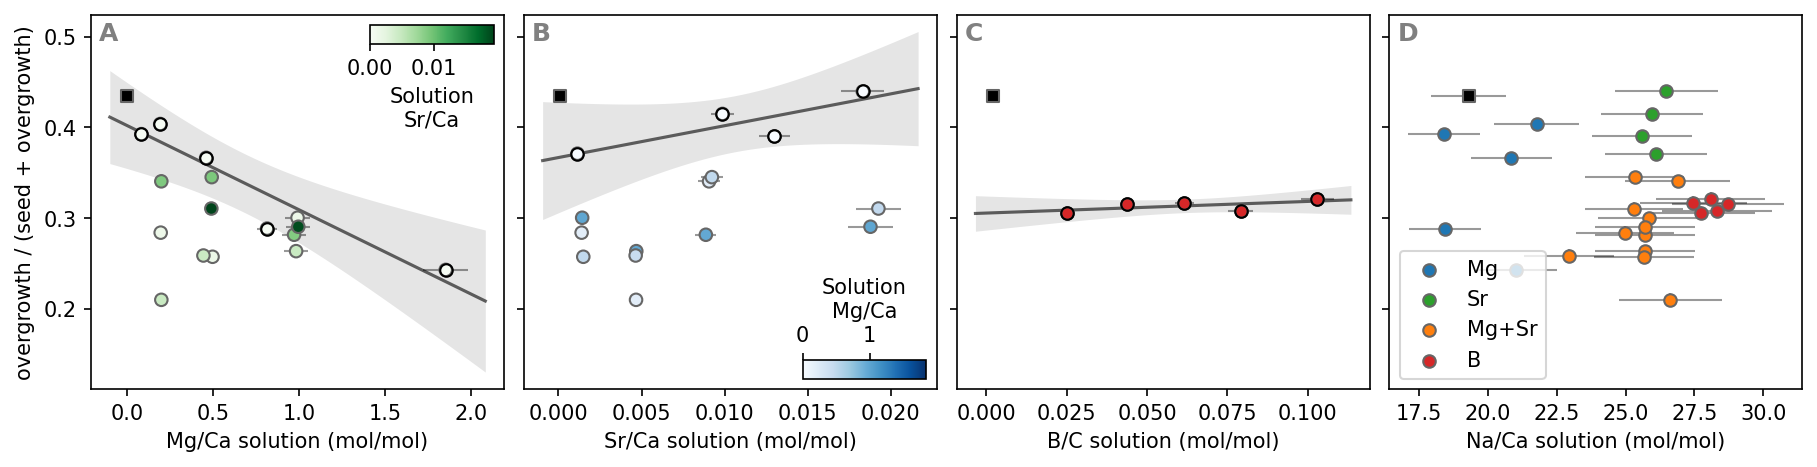

In [17]:
yvar=('derived', 'f')

fig, axs = vplt.solution_vs_yvar(dat.loc[no_high_mg & vaterite_growth], yvar=yvar, sharey=True)
for ax in axs[1:]:
    ax.get_shared_y_axes().joined(ax, axs[0])
    ax.set_ylabel(None)
axs[0].set_ylabel('overgrowth / (seed + overgrowth)')

# line of best fit for single-element experiments
for i, el in enumerate(['Mg', 'Sr', 'B']):
    denom = 'Ca'
    if el == 'B':
        denom = 'C'
    ax = axs[i]
    sub = dat.loc[no_high_mg & vaterite_growth & (dat.metadata.Experiment.isin([el]).values)]
    x = nom(sub.solution_start[f'{el}/{denom}']).ravel()
    y = nom(sub[yvar]).ravel()
    
    ax.scatter(x, y, color=(0,0,0,0), edgecolor='k', lw=1)
    p, cov = np.polyfit(x, y, 1, cov=True)
    up = un.correlated_values(p, cov)
    nx = np.linspace(*ax.get_xlim())
    pred = np.polyval(up, nx)
    ci_m = stats.t.interval(0.95, len(x) - 1)
    ax.plot(nx, nom(pred), color='k', alpha=0.6, zorder=-5)
    ax.fill_between(nx, nom(pred) + std(pred) * ci_m[0], nom(pred) + std(pred) * ci_m[1], alpha=0.1, color='k', lw=0, zorder=-5)
    
vplt.label_axes(axs)

fig.savefig('figs/Fig5.pdf')

### How does the amount of vaterite in the overgrowth change with solution chemistry?

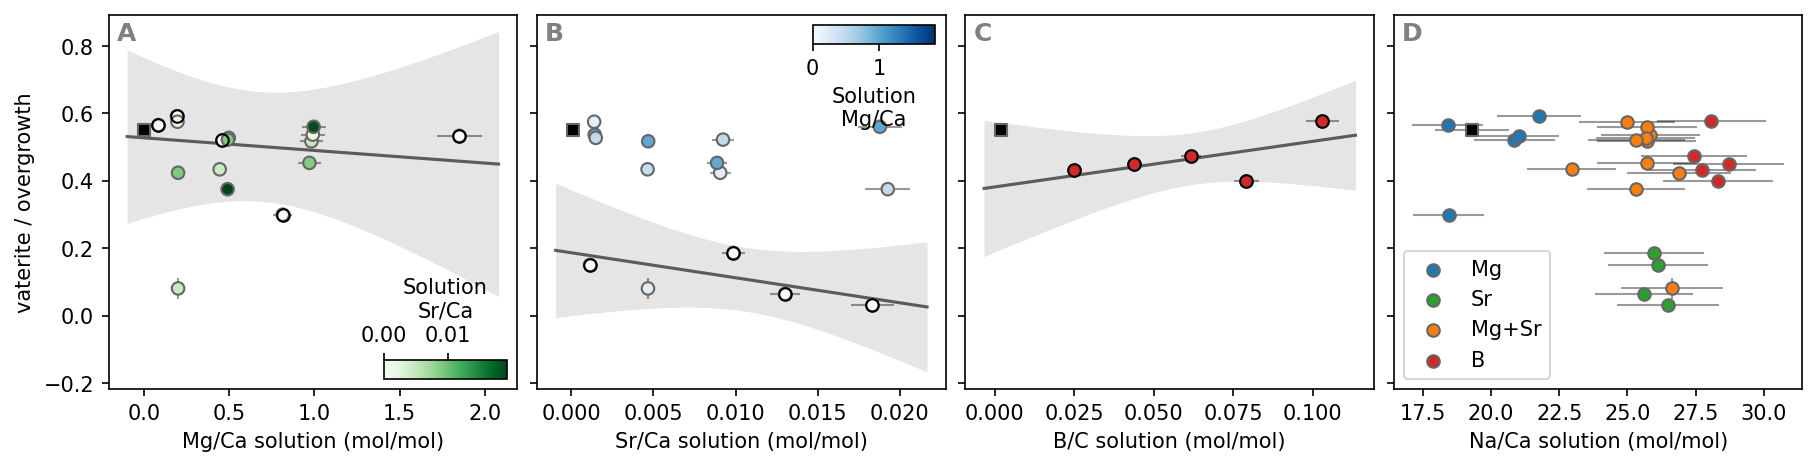

In [20]:
yvar=('overgrowth', 'F_V')
fig, axs = vplt.solution_vs_yvar(dat.loc[no_high_mg & vaterite_growth], yvar=yvar, sharey=True)
for ax in axs[1:]:
    ax.get_shared_y_axes().joined(ax, axs[0])
    ax.set_ylabel(None)
axs[0].set_ylabel('vaterite / overgrowth');

# line of best fit for single-element experiments
for i, el in enumerate(['Mg', 'Sr', 'B']):
    denom = 'Ca'
    if el == 'B':
        denom = 'C'
    ax = axs[i]
    sub = dat.loc[no_high_mg & vaterite_growth & (dat.metadata.Experiment.isin([el]).values)]
    x = nom(sub.solution_start[f'{el}/{denom}']).ravel()
    y = nom(sub[yvar]).ravel()
    
    ax.scatter(x, y, color=(0,0,0,0), edgecolor='k', lw=1)
    p, cov = np.polyfit(x, y, 1, cov=True)
    up = un.correlated_values(p, cov)
    nx = np.linspace(*ax.get_xlim())
    pred = np.polyval(up, nx)
    ci_m = stats.t.interval(0.95, len(x) - 1)
    ax.plot(nx, nom(pred), color='k', alpha=0.6, zorder=-5)
    ax.fill_between(nx, nom(pred) + std(pred) * ci_m[0], nom(pred) + std(pred) * ci_m[1], alpha=0.1, color='k', lw=0, zorder=-5)
    
vplt.label_axes(axs)

fig.savefig('figs/Fig7.pdf')

(-0.05, 1.05)

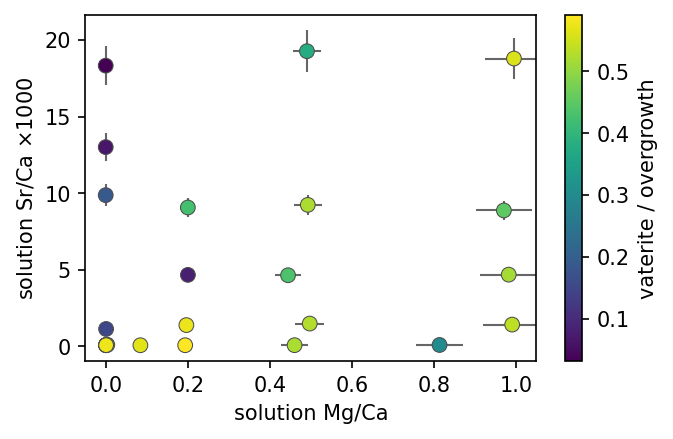

In [21]:
fig, ax = plt.subplots(1,1)

ma = ax.scatter(
    x=nom(dat.loc[no_high_mg & vaterite_growth, ('solution_start', 'Mg/Ca')]), 
    y=nom(dat.loc[no_high_mg & vaterite_growth, ('solution_start', 'Sr/Ca')]) * 1e3,
    c=nom(dat.loc[no_high_mg & vaterite_growth, ('overgrowth', 'F_V')]),
    s=50, lw=0.5, edgecolors=(.3, .3, .3)
)

ax.errorbar(
    x=nom(dat.loc[no_high_mg & vaterite_growth, ('solution_start', 'Mg/Ca')].values.ravel()), 
    xerr=std(dat.loc[no_high_mg & vaterite_growth, ('solution_start', 'Mg/Ca')].values.ravel()), 
    y=nom(dat.loc[no_high_mg & vaterite_growth, ('solution_start', 'Sr/Ca')].values.ravel()) * 1e3,
    yerr=std(dat.loc[no_high_mg & vaterite_growth, ('solution_start', 'Sr/Ca')].values.ravel()) * 1e3,
    lw=0, elinewidth=1, color=(0,0,0,0.6), zorder=-2
)

plt.colorbar(ma, ax=ax, label='vaterite / overgrowth')

ax.set_xlabel('solution Mg/Ca')
ax.set_ylabel('solution Sr/Ca $\\times 1000$')

ax.set_xlim(-0.05, 1.05)

## Overgrowth Composition

### Overgrowth composition as a function of solution chemistry

/home/oscar/.venvs/py3/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in std_dev (vectorized)
  outputs = ufunc(*args, out=...)


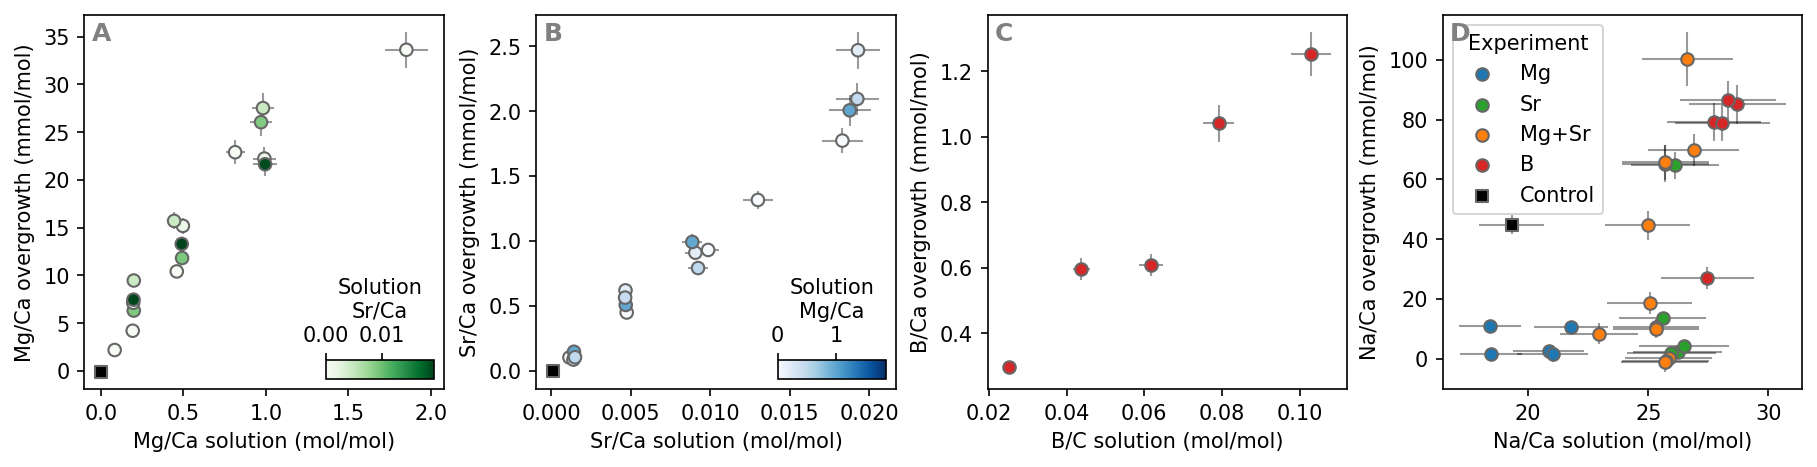

In [22]:
fig, axs = vplt.solution_vs_solid(dat.loc[no_high_mg], phase='overgrowth');

vplt.label_axes(axs)

fig.savefig('figs/Fig6.pdf')

### Vaterite composition as a function of solution chemistry

In [23]:
el = 'Mg'
dat.loc[no_high_mg & vaterite_growth & (dat.metadata.Experiment.isin([el]).values)]

Type                calcite                                      \
Quantity               B/Ca            Mg/Ca              Na/Ca   
Instrument             calc             calc               calc   
Unit                    NaN              NaN                NaN   
16          (9.0+/-1.9)e-06  0.0012+/-0.0017  0.00184+/-0.00023   
17          (3.7+/-0.8)e-06    0.003+/-0.004  0.00218+/-0.00027   
18          (6.0+/-1.2)e-06    0.006+/-0.009  0.00209+/-0.00026   
19          (2.4+/-0.5)e-06    0.011+/-0.016  0.00185+/-0.00023   
20          (5.0+/-1.0)e-07      0.03+/-0.04  0.00210+/-0.00026   

Type                                     derived metadata             \
Quantity              Sr/Ca                    f    Batch Experiment   
Instrument             calc                 calc       NA         NA   
Unit                    NaN fractional_abundance       NA         NA   
16          (5.5+/-1.6)e-06        0.393+/-0.006        1         Mg   
17          (5.7+/-1.7)e-06        0.404+/-0.006        1         Mg   
18          (5.8+/-1.7)e-06        0.366+/-0.006        1         Mg   
19          (6.8+/-2.0)e-06        0.288+/-0.006        1         Mg   
20          (5.8+/-1.7)e-06        0.243+/-0.006        1         Mg   

Type       overgrowth                              ...   solution_start  \
Quantity         B/Ca        D_B             D_Mg  ...            Sr/Ca   
Instrument       calc       calc             calc  ...             calc   
Unit          mol/mol        NaN              nan  ...          mol/mol   
16          nan+/-nan  nan+/-nan  0.0261+/-0.0023  ...  (7.9+/-0.6)e-05   
17          nan+/-nan  nan+/-nan  0.0218+/-0.0019  ...  (8.1+/-0.6)e-05   
18          nan+/-nan  nan+/-nan  0.0226+/-0.0020  ...  (8.3+/-0.6)e-05   
19          nan+/-nan  nan+/-nan  0.0281+/-0.0025  ...  (9.6+/-0.7)e-05   
20          nan+/-nan  nan+/-nan  0.0182+/-0.0016  ...  (8.2+/-0.6)e-05   

Type                   vaterite                                               \
Quantity      pH_NBS       B/Ca        D_B           D_Mg               D_Na   
Instrument electrode       calc       calc           calc               calc   
Unit              NA    mol/mol        NaN            NaN                NaN   
16             8.209  nan+/-nan  nan+/-nan  0.035+/-0.016  0.00098+/-0.00018   
17             8.193  nan+/-nan  nan+/-nan  0.027+/-0.014  0.00076+/-0.00014   
18             8.200  nan+/-nan  nan+/-nan  0.031+/-0.019  0.00014+/-0.00014   
19             8.198  nan+/-nan  nan+/-nan    0.06+/-0.05    0.0001+/-0.0004   
20             8.209  nan+/-nan  nan+/-nan  0.022+/-0.018  0.00006+/-0.00023   

Type                                                                          
Quantity            D_Sr            Mg/Ca            Na/Ca             Sr/Ca  
Instrument          calc             calc             calc              calc  
Unit                 NaN          mol/mol          mol/mol           mol/mol  
16          -0.22+/-0.13  0.0030+/-0.0013  0.0180+/-0.0030  (-1.8+/-1.0)e-05  
17          -0.15+/-0.11  0.0053+/-0.0027  0.0165+/-0.0028  (-1.2+/-0.9)e-05  
18          -0.16+/-0.15    0.014+/-0.009  0.0030+/-0.0029  (-1.3+/-1.2)e-05  
19          -0.70+/-0.32      0.05+/-0.04    0.001+/-0.007  (-6.7+/-3.1)e-05  
20           0.06+/-0.27    0.040+/-0.033    0.001+/-0.005   (0.5+/-2.2)e-05  

[5 rows x 61 columns]

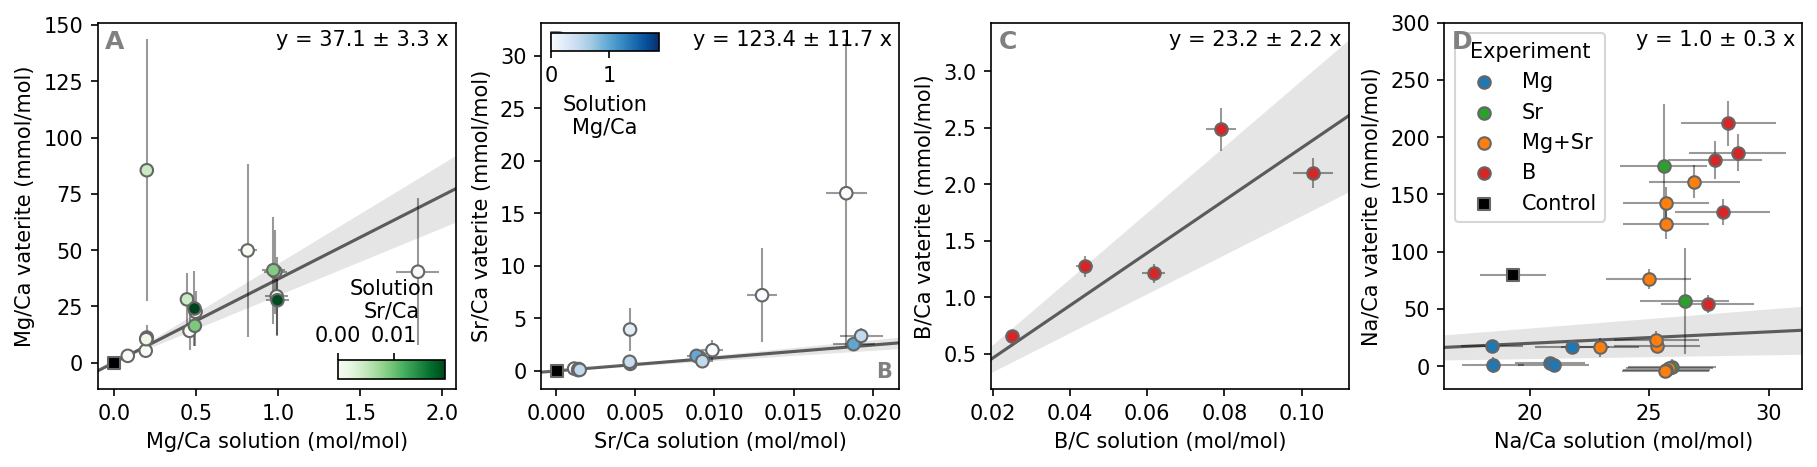

In [24]:
fig, axs = vplt.solution_vs_solid(dat=dat.loc[no_high_mg & vaterite_growth], phase='vaterite', vars=['Mg/Ca', 'Sr/Ca', 'B/C', 'Na/Ca'])

def calc_D(x, D):
    return x * D

# line of best fit for single-element experiments
for i, el in enumerate(['Mg', 'Sr', 'B', 'Na']):
    denom = 'Ca'
    if el == 'B':
        denom = 'C'
    yvar = ('vaterite', f'{el}/Ca')
    ax = axs[i]
    ind = no_high_mg & vaterite_growth & (dat.metadata.Experiment.NA.NA.str.contains(el).values.reshape(-1,1))
    m = 1e3
    if el == 'Na':
        ind = no_high_mg & vaterite_growth
    sub = dat.loc[ind]
    x = nom(sub.solution_start[f'{el}/{denom}']).ravel()
    y = nom(sub[yvar]).ravel() * m
    yerr = std(sub[yvar]).ravel() * m
    
    # ax.scatter(x, y, color=(0,0,0,0), edgecolor='k', lw=1)
    
    p, cov = optimize.curve_fit(calc_D, x, y, sigma=yerr)
    # p, cov = np.polyfit(x, y, 1, cov=True)
    up = un.correlated_values(p, cov)
    ax.set_xlim(ax.get_xlim())
    nx = np.linspace(*ax.get_xlim())
    # pred = np.polyval(up, nx)
    pred = calc_D(nx, up)
    ci_m = stats.t.interval(0.95, len(x) - 1)
    ax.plot(nx, nom(pred), color='k', alpha=0.6, zorder=-5)
    ax.fill_between(nx, nom(pred) + std(pred) * ci_m[0], nom(pred) + std(pred) * ci_m[1], alpha=0.1, color='k', lw=0, zorder=-5)
    ax.text(0.98, 0.98, f'y = {nom(up).item():.1f} ± {std(up).item():.1f} x', ha='right', va='top', transform=ax.transAxes)

vplt.label_axes(axs)
axs[1].text(0.98, 0.02, 'B', color='grey', ha='right', va='bottom', weight='bold', fontsize=10, transform=axs[1].transAxes)

axs[-1].set_ylim(-20, 300)

fig.savefig('figs/Fig12.pdf')

Add on partition coefficients from these lines.

### Overgrowth vs. vaterite composition

/home/oscar/.venvs/py3/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in std_dev (vectorized)
  outputs = ufunc(*args, out=...)


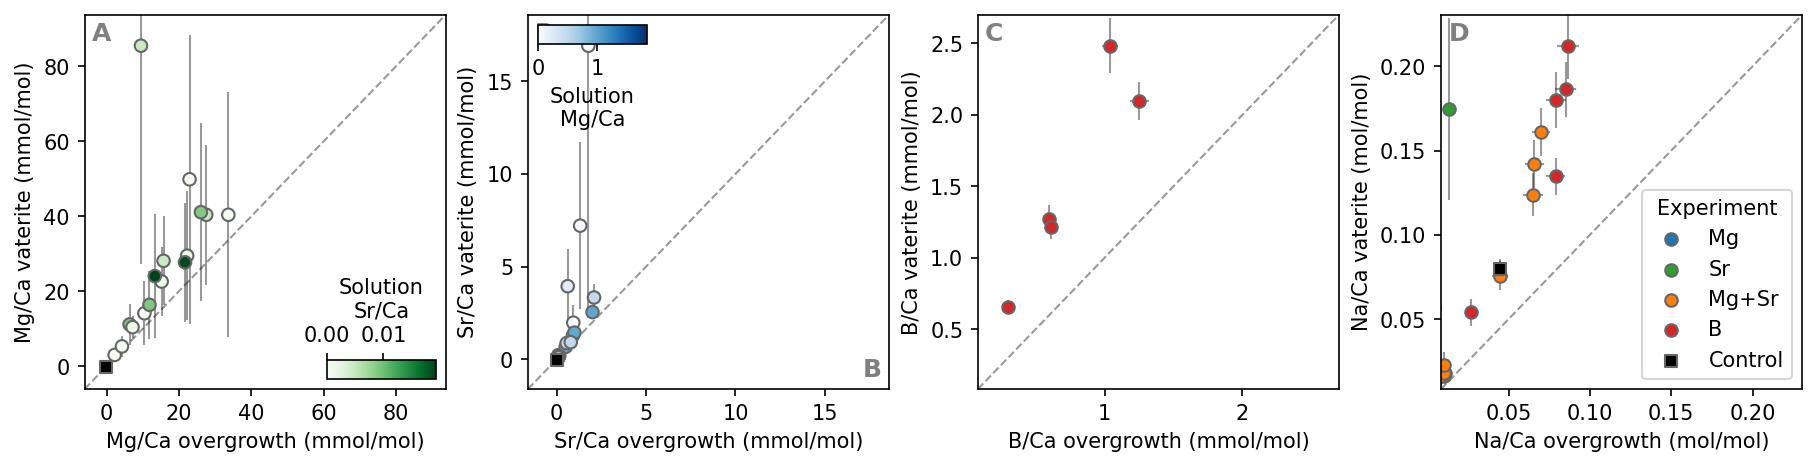

In [25]:
fig, axs = vplt.solid_vs_solid(dat=dat.loc[no_high_mg & vaterite_growth], xphase='overgrowth', yphase='vaterite', vars=['Mg/Ca', 'Sr/Ca', 'B/Ca', 'Na/Ca']);

vplt.label_axes(axs)
axs[1].text(0.98, 0.02, 'B', color='grey', ha='right', va='bottom', weight='bold', fontsize=12, transform=axs[1].transAxes)

fig.savefig('figs/Fig13a.pdf')

### Calcite vs. vaterite composition

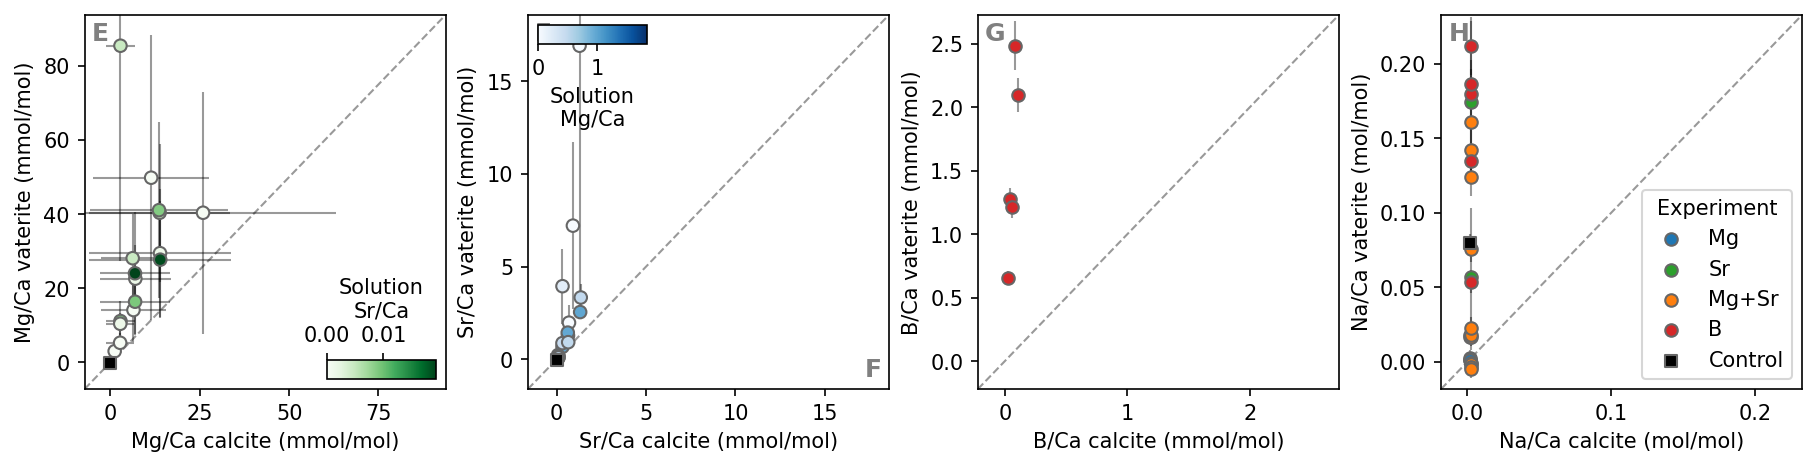

In [26]:
fig, axs = vplt.solid_vs_solid(dat=dat.loc[no_high_mg & vaterite_growth], xphase='calcite', yphase='vaterite', vars=['Mg/Ca', 'Sr/Ca', 'B/Ca', 'Na/Ca']);

vplt.label_axes(axs, labels='EFGH')
axs[1].text(0.98, 0.02, 'F', color='grey', ha='right', va='bottom', weight='bold', fontsize=12, transform=axs[1].transAxes)


fig.savefig('figs/Fig13b.pdf')